In [1]:
import rosalia as rs
import pandas as pd
from astroquery.mpc import MPC
import ephessos as ep
obs = MPC.get_observatory_codes()
print(obs[obs["Name"] == "Euclid"])
print(obs[obs["Name"] == "Hubble Space Telescope"])
print(obs[obs["Name"] == "James Webb Space Telescope"])
print(obs[obs["Name"] == "Nancy Grace Roman Space Telescope"])



Code Longitude cos sin  Name 
---- --------- --- --- ------
 273        --  --  -- Euclid
Code Longitude cos sin          Name         
---- --------- --- --- ----------------------
 250        --  --  -- Hubble Space Telescope
Code Longitude cos sin            Name           
---- --------- --- --- --------------------------
 274        --  --  -- James Webb Space Telescope
Code Longitude cos sin                Name              
---- --------- --- --- ---------------------------------
 289        --  --  -- Nancy Grace Roman Space Telescope


In [2]:
# Telescope definition object 
# telescope = {"pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "detector_shape": [NAXIS1, NAXIS2], "pixscale": pixscale,
#              "R_mirror": R_mirror, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

from astropy.time import Time
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import rosalia as rs

class exposure():
    
    def __init__(self, filename=None, telescope=None):

        if telescope is not None: 
            
            self.TELESCOP = telescope['TELESCOP']
            self.INSTRUME = telescope['INSTRUME']
            self.DETECTOR = telescope['DETECTOR']
            self.DATA_SHAPE = telescope['DATA_SHAPE']
            self.RA_TARG = telescope["pointing"][0]
            self.DEC_TARG = telescope["pointing"][1]
            self.PA = telescope['PA_Y']
            self.EXPSTART = telescope['EXPSTART']
            self.EXPTIME = telescope['EXPTIME']
            self.EXPMID = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s/2).mjd
            self.EXPEND = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s).mjd
            # self.PHYSPIX = telescope['PHYSPIX']
            self.PIXSCALE = telescope['PIXSCALE']
            # self.EXPSTART_ISOT = 
            self.MPC_OBSLOC = self.get_mpc_observer_location()
            self.JPL_OBSLOC = self.get_jpl_observer_location()
            self.FILTER_IDENTITY = rs.telescopes.find_filter_in_svo(wavelength=telescope["FILTER_PARAMS"]["NAME"],
                                                                    telescope=telescope["FILTER_PARAMS"]["TELESCOPE"],
                                                                    instrument=telescope["FILTER_PARAMS"]["INSTRUMENT"],
                                                                    detector=telescope["FILTER_PARAMS"]["DETECTOR"], verbose=False)
            # self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
            self.SCIEXTS = [0]

            header = rs.utils.create_custom_wcs(crpix=np.array(self.DATA_SHAPE)/2, 
                                                         crval=[self.RA_TARG, self.DEC_TARG], 
                                                         cdelt=[-self.PIXSCALE,self.PIXSCALE], 
                                                         crota=[-self.PA,-self.PA], 
                                                         projection="TAN")
            
            header["NAXIS1"] = self.DATA_SHAPE[0]
            header["NAXIS2"] = self.DATA_SHAPE[1]

            from astropy.wcs import WCS
            self.ASTROPYWCS = [WCS(header)]
            self.FPA_NEAR_RADIUS = self.get_max_angular_size()
            import os 
            self.FILENAME = os.getcwd() + "/" + self.TELESCOP + "_RA_" + '{:07.3f}'.format(self.RA_TARG) +\
                                     "_DEC_" + '{:07.3f}'.format(self.DEC_TARG) +\
                                     "_MJD_" + '{:07.5f}'.format(self.EXPSTART) +\
                                     "_PA_" + '{:06.2f}'.format(self.PA) + ".fits"

        if filename is not None:
            exposure_identity = rs.utils.exposure_inspector(filename, lite=False)
        
            self.FILENAME = exposure_identity['FILENAME']
            self.TELESCOP = exposure_identity['TELESCOP']
            self.INSTRUME = exposure_identity['INSTRUME']
            self.DETECTOR = exposure_identity['DETECTOR']
            self.RA_TARG = exposure_identity['RA_TARG']
            self.DEC_TARG = exposure_identity['DEC_TARG']
            self.EXPSTART = exposure_identity['EXPSTART']
            self.EXPTIME = exposure_identity['EXPTIME']
            self.EXPMID = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s/2).mjd
            self.EXPEND = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s).mjd
            self.BUNIT = exposure_identity['BUNIT']
            self.EXPSTART_ISOT = exposure_identity['EXPSTART_ISOT']
            self.PA = exposure_identity['PA']
            # self.SCA = exposure_identity['SCA']
            self.HST_TYPE = exposure_identity['HST_TYPE']
            self.FILTER = exposure_identity['FILTER']
            self.FILTER_IDENTITY = exposure_identity['FILTER_IDENTITY']
            # self.PHYSPIX = exposure_identity['PHYSPIX']
            self.PIXSCALE = exposure_identity['PIXSCALE']
            self.SCIEXTS = exposure_identity['SCIEXTS']
            self.DATA_SHAPE = exposure_identity['DATA_SHAPE']
            self.ASTROPYWCS = exposure_identity['ASTROPYWCS']
            self.FILETYPE = exposure_identity['FILETYPE']
            self.MPC_OBSLOC = self.get_mpc_observer_location()
            self.JPL_OBSLOC = self.get_jpl_observer_location()
            # self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
            self.FPA_NEAR_RADIUS = self.get_max_angular_size()


    def get_jpl_observer_location(self):
        if self.TELESCOP == "HST" or self.TELESCOP == "Hubble": return("500@-48")
        if self.TELESCOP == "RST" or self.TELESCOP == "Roman": return("500@-211")
        if self.TELESCOP == "Moon": return("500@301")
        if self.TELESCOP == "ARTEMIS-II": return("500@-1024")
        if self.TELESCOP == "Euclid": return("500@-680")
        return("500") # If none is valid, return the center of the Earth


    def get_mpc_observer_location(self):
        if self.TELESCOP == "HST" or self.TELESCOP == "Hubble": return("250")
        if self.TELESCOP == "RST" or self.TELESCOP == "Roman": return("289")
        if self.TELESCOP == "Euclid": return("273")


    def get_detector_corners(self):
        detector_corners = []
        for i in range(len(self.SCIEXTS)):
            detector_corners.append(rs.detectors.get_detector_corners(self.ASTROPYWCS[i]))
        return(detector_corners)
    

    def get_max_angular_size(self):
        return(rs.utils.find_max_angular_size_of_image(wcs=self.ASTROPYWCS, ra_cen=self.RA_TARG, dec_cen=self.DEC_TARG))
    

    def plot_footprint(self, verbose=True, ax=None, color='red', label=None):
        print("Hey! plot_footprint")
        if verbose: print("Finding ra dec constraints")
        # ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=verbose)
        if verbose: print("Getting detector corners")
        exp_corners = self.get_detector_corners()
        if verbose: print("Plotting...")
        if ax is None:
            fig, ax = plt.subplots(figsize=(8,8))
        for i in range(len(self.SCIEXTS)):
            x = np.array(exp_corners[i]["corners_world"][:,0].tolist() + [exp_corners[i]["corners_world"][0,0]])
            y = np.array(exp_corners[i]["corners_world"][:,1].tolist() + [exp_corners[i]["corners_world"][0,1]])
            ax.plot(x, y, color=color, label=label)
            # ax.set_xlim(ra_dec_constraints["ra_max"], ra_dec_constraints["ra_min"])
            # ax.set_ylim(ra_dec_constraints["dec_min"], ra_dec_constraints["dec_max"])
            ax.set_xlabel("Right Ascension (degree)")
            ax.set_ylabel("Declination (degree)")
        return(ax)
    

    def find_nearby_ssos(self):
        import ephessos as ep 
        sso_cone_search = ep.core.cone_search(ra=self.RA_TARG, dec=self.DEC_TARG, mjd=self.EXPSTART, search_radius=self.FPA_NEAR_RADIUS, verbose=False)
        return(sso_cone_search)


    def get_nearby_sources(self, g_mag_max=15, verbose=False):
        hybrid_catalog = rs.psf.get_hybrid_catalog(ra=self.RA_TARG, dec=self.DEC_TARG,
                                                   radius=1,
                                                   lambda_ref=self.FILTER_IDENTITY["filter_lambda_ref"],
                                                   MJD=self.EXPSTART,
                                                   observer=self.TELESCOP,
                                                   g_mag_max = g_mag_max,
                                                   verbose=verbose,
                                                   query_filename=self.FILENAME.replace(".fits", ".csv"))
        return(hybrid_catalog)
        

    def get_nearby_ssos(self, ra=None, dec=None, radius=None, mjd=None, verbose=False, time_step="30s"):
        import ephessos as ep
        if ra==None: ra = self.RA_TARG
        if dec==None: dec = self.DEC_TARG
        if radius==None: radius = self.FPA_NEAR_RADIUS*60*60
        if mjd==None: mjd = self.EXPSTART

        cone_search = ep.core.cone_search(ra=ra, dec=dec, mjd=mjd, 
                                          search_radius=radius, observatory=self.MPC_OBSLOC, verbose=verbose)
        ephessos_df = ep.core.ephessos(sso_search=cone_search, mjd_start=self.EXPSTART, mjd_end=self.EXPEND, 
                                       obs_center=self.JPL_OBSLOC, step_size=time_step, verbose=verbose)
        return(cone_search, ephessos_df)
    

    def make_dummy(self, binning=1):
        data = []
        headers = []
        for SCIEXT in self.SCIEXTS:
            # Create a new WCS object.  The number of axes must be set from the start
            w = self.ASTROPYWCS[SCIEXT]
    
            # Setting some dummy image
            image_data = np.random.normal(loc=0, scale=1, 
                                          size=[int(self.DATA_SHAPE[0]/binning),
                                                int(self.DATA_SHAPE[1]/binning)])

            # Now, write out the WCS object as a FITS header
            header = w.to_header()
            header["EXTNAME"] = "SCI"
            header["RA_TARG"] = self.RA_TARG
            header["DEC_TARG"] = self.DEC_TARG
            header["EXPSTART"] = self.EXPSTART
            header["EXPEND"] = self.EXPEND
            header["PA"] = self.PA
            header["TELESCOP"] = self.TELESCOP
            header["INSTRUME"] = self.INSTRUME
            header["DETECTOR"] = self.DETECTOR

            # header is an astropy.io.fits.Header object.  We can use it to create a new
            # PrimaryHDU and write it to a file.
            data.append(image_data)
            headers.append(header)
        
        rs.utils.save_fits(data, self.FILENAME, headers)
        return(self.FILENAME)

    



Hey! plot_footprint
Finding ra dec constraints
Getting detector corners
Plotting...


'/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/STARFOX_RA_100.000_DEC_023.000_MJD_61000.00000_PA_032.00.fits'

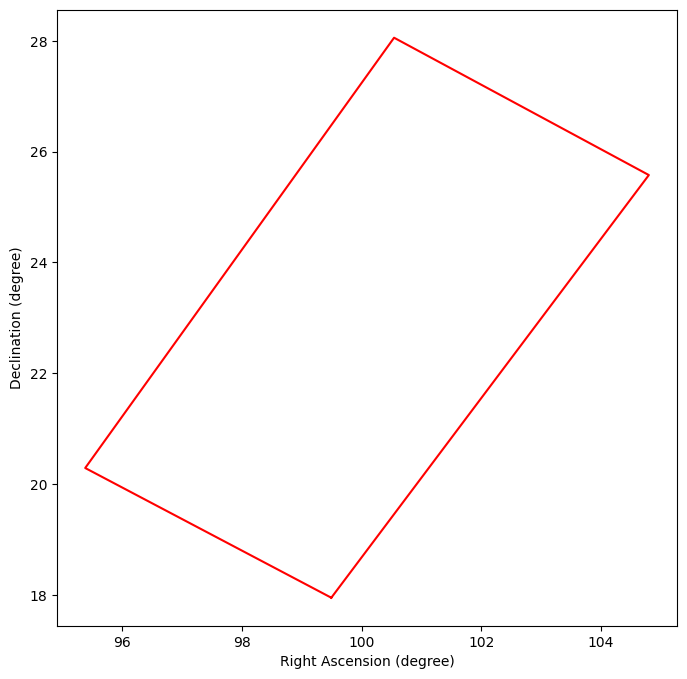

In [3]:
TELESCOP = "STARFOX"
INSTRUME = "STARFOX"
DETECTOR = "STARFOX"
RA_TARG = 100
DEC_TARG = 23
PA_Y = 32
NAXIS1=2048
NAXIS2=4096
PIXSCALE=8/60/60
R_mirror=1
OBSLOC=273
EXPSTART=61000
EXPTIME=10
FILTER_PARAMS={"NAME": "F606W", "TELESCOPE": "HST", "INSTRUMENT": "ACS", "DETECTOR": "WFC"}

telescope = {"TELESCOP":TELESCOP, "INSTRUME":INSTRUME, "DETECTOR": DETECTOR,
              "pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "DATA_SHAPE": [NAXIS1, NAXIS2], "PIXSCALE": PIXSCALE,
             "R_mirror": R_mirror, "FILTER_PARAMS":FILTER_PARAMS, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

custom_exposure = exposure(telescope=telescope)
custom_exposure.get_detector_corners()
custom_exposure.plot_footprint()
custom_exposure.ASTROPYWCS[0].proj_plane_pixel_scales()

custom_exposure.make_dummy()

In [4]:
dummy_name = '/Users/aborlaff/NASA/ROSALIA/notebooks/DEVEL/STARFOX_RA_100.000_DEC_023.000_MJD_61000.00000_PA_032.00.fits'
print(custom_exposure.FILTER_IDENTITY)
i=0
zodiacal_background = rs.sky.get_zodiacal_background(input_name=dummy_name,
                                                      ext=custom_exposure.SCIEXTS[i],
                                                      wavelength=custom_exposure.FILTER_IDENTITY["filter_id"],
                                                      telescope=custom_exposure.TELESCOP,
                                                      instrument=custom_exposure.INSTRUME,
                                                      detector=custom_exposure.DETECTOR,
                                                      expstart=custom_exposure.EXPSTART,
                                                      step=1000, zody_mode="zodipy",
                                                      nbins_wavelength=20, obslocin=3,
                                                      grid_method="random", output_units="e/s",
                                                      verbose=False)

{'filter_id': 'HST/ACS_WFC.F606W', 'filter_transmission_curve': <Table length=2715>
Wavelength Transmission
 Angstrom              
 float64     float64   
---------- ------------
    4569.0  9.66764e-05
    4570.0   0.00010671
    4571.0   0.00011673
    4572.0  0.000126749
    4573.0  0.000136765
    4574.0  0.000146779
    4575.0   0.00015679
    4576.0  0.000166799
    4577.0  0.000176806
       ...          ...
    7275.0  0.000127173
    7276.0  0.000123225
    7277.0  0.000119279
    7278.0  0.000115334
    7279.0  0.000111391
    7280.0   0.00010745
    7281.0  0.000103509
    7282.0  9.95689e-05
    7283.0  9.56309e-05, 'filter_lambda_ref': <Quantity 5809.25977515 Angstrom>, 'filter_lambda_min': <Quantity 4681. Angstrom>, 'filter_lambda_max': <Quantity 7118. Angstrom>, 'filter_lambda_width': <Quantity 1771.88043556 Angstrom>, 'filter_transmission_ref': array(0.41824189), 'wavelength': 'F606W', 'telescope': 'HST', 'instrument': 'ACS', 'detector': 'WFC'}


KeyError: 'EXPSTART'

In [ ]:
# filename="/Users/aborlaff/NASA/AURELIEN/UFO/MAST_2022-05-05T1554/HST/ic1601hsq/ic1601hsq_flt.fits"
# hst_exp = exposure(filename="/Users/aborlaff/NASA/AURELIEN/UFO/MAST_2022-05-05T1554/HST/ic1601hsq/ic1601hsq_flt.fits")
filename = "/Users/aborlaff/Downloads/MAST_2026-05-08T2317/HST/j90za9qmq/j90za9qmq_flc.fits"
hst_exp = exposure(filename=filename)
hst_exp.FPA_NEAR_RADIUS = hst_exp.FPA_NEAR_RADIUS
# print(hst_exp.FPA_NEAR_RADIUS)
cone_search, ephessos_df = hst_exp.get_nearby_ssos(time_step="1m")

import matplotlib.pyplot as plt
from tqdm import tqdm

hst_exp.plot_footprint()

for i in tqdm(range(len(ephessos_df))):
    # print(ephessos_df[i]["Designation"][0])
    plt.plot(ephessos_df[i]["RA_deg_ICRF"], ephessos_df[i]["DEC_deg_ICRF"], label=ephessos_df[i]["Designation"].iloc[0])
    plt.legend(frameon=False)

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
filename = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269.fits"

artemis_fits = fits.open(filename)
# plt.imshow(np.flip(artemis_fits[0].data[1,:,:], axis=0))
artemis_fits[0].header

In [ ]:
hst_exp.PIXSCALE.to("arcsec")

In [ ]:
# Try the Artemis image 
import rosalia as rs
# Fix the flip in the Y-axis
filename = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269.fits"
artemis_fits = fits.open(filename)
#artemis_fits[0].data = np.flip(artemis_fits[0].data[1,:,:], axis=0)
#artemis_fits[0].header["CD1_1"] = -artemis_fits[0].header["CD1_1"]
#artemis_fits[0].header["CD1_2"] = -artemis_fits[0].header["CD1_2"]
#artemis_fits[0].header["CD2_1"] = -artemis_fits[0].header["CD2_1"]
#artemis_fits[0].header["CD2_2"] = -artemis_fits[0].header["CD2_2"]
artemis_fits.verify("silentfix")
fixed_artemis_name = filename.replace(".fits", "_fix.fits")
artemis_fits.writeto(fixed_artemis_name, overwrite=True)

rs.utils.run_swarp(pattern=fixed_artemis_name, outname="/Users/aborlaff/NASA/LUNARIS/ART002-E-28269_aligned.fits", resample=False)
filename = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269_aligned.fits"
filename_cal = "/Users/aborlaff/NASA/LUNARIS/ART002-E-28269_aligned_cal.fits"

# Fix the header so it is taken by ROSALIA
from astropy.io import fits
from astropy.time import Time
from astropy.wcs import WCS

artemis_fits = fits.open(filename)
artemis_fits[0].data = artemis_fits[0].data[:,:]
wcs = WCS(header=artemis_fits[0], fobj=artemis_fits, naxis=2)

artemis_fits[0].header["EXPSTART"] = Time('2026-04-07T21:31:40.000', scale="utc").mjd # ISOT FORMAT: '2004-09-15T21:59:21.929'
artemis_fits[0].header["EXPTIME"] = 600
artemis_fits[0].header["BUNIT"] = "cps"
artemis_fits[0].header["TELESCOP"] = "ARTEMIS-II"
artemis_fits[0].header["FILTER"] = "g"
artemis_fits[0].header["INSTRUME"] = "SDSS"
artemis_fits[0].header["DETECTOR"] = "SDSS"
artemis_fits[0].header["EXTNAME"] = "SCI"
#artemis_fits[0].header["PA"] = -6.8


artemis_fits.verify("silentfix")
artemis_fits.writeto(filename_cal, overwrite=True)

artemis_exp = exposure(filename=filename_cal)


In [ ]:
cone_search, ephessos_df = artemis_exp.get_nearby_ssos(time_step="1m")

import matplotlib.pyplot as plt
from tqdm import tqdm

artemis_exp.plot_footprint()
xy_ssos = []

canvas = fits.open(filename_cal)
canvas[0].data = np.zeros(canvas[0].data.shape)
import copy 
for i in tqdm(range(len(ephessos_df))):
    # print(ephessos_df[i]["Designation"][0])
    plt.plot(ephessos_df[i]["RA_deg_ICRF"],
             ephessos_df[i]["DEC_deg_ICRF"],
             label=ephessos_df[i]["Designation"].iloc[0], linewidth=5)
    plt.legend(frameon=False)

    xy = rs.utils.radec_to_xy(ra=ephessos_df[i]["RA_deg_ICRF"], dec=ephessos_df[i]["DEC_deg_ICRF"], fits_name=filename_cal, ext=0)
    # print(xy)
    xy_ssos.append(xy)
    try:
        canvas[0].data[np.array(xy[0], dtype="int32"),np.array(xy[1], dtype="int32")] = i
    except:
        print("Out of bonds")
canvas.verify("silentfix")
canvas.writeto("artemis_sats_mask.fits", overwrite=True)


In [ ]:
plt.plot(ephessos_df[i]["RA_deg_ICRF"],
         ephessos_df[i]["DEC_deg_ICRF"],
         label=ephessos_df[i]["Designation"].iloc[0], linewidth=5)

In [ ]:
artemis_exp.plot_footprint(verbose=True)

In [ ]:
import copy 
self = copy.deepcopy(artemis_exp) 
verbose=True
print("Hey! plot_footprint")
if verbose: print("Finding ra dec constraints")
ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=verbose)
print("test1")
print(ra_dec_constraints)
print("test")

In [ ]:
if False:
    if True:
        self = copy.deepcopy(artemis_exp) 
        verbose=True
        # def plot_footprint(self, verbose=True, ax=None, color='red', label=None):
        print("Hey! plot_footprint")
        if verbose: print("Finding ra dec constraints")
        ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=verbose)
        if verbose: print("Getting detector corners")
        exp_corners = self.get_detector_corners()
        if verbose: print("Plotting...")
        if ax is None:
            fig, ax = plt.subplots(figsize=(8,8))
        for i in range(len(self.SCIEXTS)):
            x = np.array(exp_corners[i]["corners_world"][:,0].tolist() + [exp_corners[i]["corners_world"][0,0]])
            y = np.array(exp_corners[i]["corners_world"][:,1].tolist() + [exp_corners[i]["corners_world"][0,1]])
            ax.plot(x, y, color=color, label=label)
            ax.set_xlim(ra_dec_constraints["ra_max"], ra_dec_constraints["ra_min"])
            ax.set_ylim(ra_dec_constraints["dec_min"], ra_dec_constraints["dec_max"])
            ax.set_xlabel("Right Ascension (degree)")
            ax.set_ylabel("Declination (degree)")
        # return(ax)

In [ ]:
artemis_exp.plot_footprint(verbose=True)

In [ ]:
print(artemis_exp.TELESCOP)

In [ ]:
a = fits.open(filename_cal)
wcs = WCS(a[0], a, naxis=2)
header = wcs.to_header()
print(header)
print("PC1_2" in header)

In [ ]:
type(header)

In [ ]:
header = exposure_identity["ASTROPYWCS"][0].to_header()
import numpy as np

theta_rad = np.arctan2(-header["PC1_2"], header["PC2_2"])

# Convert to degrees
np.degrees(theta_rad)


In [ ]:
header = exposure_identity["ASTROPYWCS"][0].to_header()
header

In [ ]:
artemis_exp = exposure(filename=filename_cal)
artemis_exp.FPA_NEAR_RADIUS = hst_exp.FPA_NEAR_RADIUS
# print(hst_exp.FPA_NEAR_RADIUS)
cone_search, ephessos_df = artemis_exp.get_nearby_ssos(time_step="1m")

import matplotlib.pyplot as plt
from tqdm import tqdm

artemis_exp.plot_footprint()

for i in tqdm(range(len(ephessos_df))):
    # print(ephessos_df[i]["Designation"][0])
    plt.plot(ephessos_df[i]["RA_deg_ICRF"], ephessos_df[i]["DEC_deg_ICRF"], label=ephessos_df[i]["Designation"].iloc[0])
    plt.legend(frameon=False)

In [ ]:
# Parallax calculations 

d_Earth_sun = 149.60E+9 #m
d_Earth_moon = 385000E+3 # m
sphere_moon = 0.0643E+6 # m
r_Earth = 6378E+3 # m 
h_hubble = 550E+3 # m
import numpy as np
parallax = 2*(r_Earth + h_hubble)/d_Earth_sun/np.pi*180*60*60
print(parallax)

In [ ]:
# Parallax calculations 
# One of the trails is about 1000 arcsec long. How fast does that have to be? 
import numpy as np
exptime = 10 # seconds 

parallax = np.tan(1000/60/60/exptime)*d_Earth_sun
print("At 1 AU")
print(str(parallax/1000) + " km/s") 

parallax = 1000/60/60*d_Earth_moon/10
print("At 1 Moon-Earth Distance")
print(str(parallax/1000) + " km/s") 
print(str(60*60*parallax/1000) + " km/h") 


parallax = 1000/60/60*sphere_moon/10
print("At Moon")
print(str(parallax/1000) + " km/s") 
print(str(60*60*parallax/1000) + " km/h") 



In [ ]:
0.0643

In [ ]:
for i in range(len(ssos)):
    print(str(ssos[i]["RA_deg_ICRF"][0]) + " " + str(ssos[i]["DEC_deg_ICRF"][0]))

In [ ]:
from astropy.time import Time
#t1 = Time('2006-01-01', scale="tt")
t1 = Time(hst_exp.EXPSTART, format="mjd", scale="tt")
t2 = Time(hst_exp.EXPEND, format="mjd", scale="tt")
#t2 = Time('2006-01-02', scale="tt")

print(t1.isot)
print(t2.isot)
# print(t.td)

In [ ]:
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND='499'&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@399'&START_TIME='2006-01-01'&STOP_TIME='2006-01-20'&STEP_SIZE='1%20d'&QUANTITIES='1,9,20,23,24,29'

In [ ]:
ssos

In [ ]:
import pympc
pympc.utils.ensure_obs_codes_cached(update=True)

In [ ]:
custom_exposure.get_detector_corners()


In [ ]:
nearby_catalog = custom_exposure.get_nearby_sources()

In [ ]:
# Zodiacal light STScI
# roman_notebooks/notebooks/background_visualization_tool/rbt.py     def read_bkg_data_from_url(self, cache_file, verbose=False):

In [ ]:


TELESCOP="STARFOX"
RA_TARG = 100
DEC_TARG = 23
PA_Y = 32
NAXIS1=2048
NAXIS2=4096
PIXSCALE=8/60/60
R_mirror=1
OBSLOC=273
EXPSTART=61000
EXPTIME=10
FILTER_PARAMS={"NAME": "F606W", "TELESCOPE": "HST", "INSTRUMENT": "ACS", "DETECTOR": "WFC"}

telescope = {"TELESCOP":TELESCOP, "pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "DATA_SHAPE": [NAXIS1, NAXIS2], "PIXSCALE": PIXSCALE,
             "R_mirror": R_mirror, "FILTER_PARAMS":FILTER_PARAMS, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

custom_exposure = exposure(telescope=telescope)
custom_exposure.get_detector_corners()
custom_exposure.plot_footprint()
custom_exposure.ASTROPYWCS[0].proj_plane_pixel_scales()

In [ ]:
import glob
roman_fits = glob.glob("/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI*[0-9].fits")

for i in range(len(roman_fits)):
    print(roman_fits[i])
    roman_exposure = exposure(roman_fits[i])
    roman_exposure.plot_footprint()
    roman_exposure.find_nearby_ssos()

In [ ]:
(/60/60*4096)**2

In [ ]:
# roman_exposure.get_detector_corners()
rs.utils.find_max_angular_size_of_image(wcs=roman_exposure.ASTROPYWCS)    

In [ ]:
ep.core.get_last_mpcorb()

In [ ]:
exp_corners[0]["corners_world"][:,0].tolist()

In [ ]:
import pympc 
pympc.update_catalogue()

In [ ]:
from astropy.coordinates import SkyCoord

from astropy.time import Time

from astroquery.jplhorizons import Horizons
import numpy as np

epoch_start = Time('2026-04-02 01:58:32.3051', scale="tt")
epoch_end   = Time('2026-04-10 23:54:22.857', scale="tt")
epochs = {'start': epoch_start.isot, 'stop': epoch_end.isot, 'step': "1m"}

q = Horizons('2026-069A', location='@399', epochs=epochs)

tab = q.vectors(refplane='earth')
import matplotlib.pyplot as plt
plt.plot(tab["x"], tab["y"])

In [ ]:
from astropy.coordinates import SkyCoord

from astropy.time import Time

from astroquery.jplhorizons import Horizons
import numpy as np

epoch_start = Time('2006-04-02 01:58:32.3051', scale="tt")
epoch_end   = Time('2006-04-10 23:54:22.857', scale="tt")
epochs = {'start': epoch_start.isot, 'stop': epoch_end.isot, 'step': "1m"}

q = Horizons('Hubble', location='@399', epochs=epochs)

tab = q.vectors(refplane='earth')
import matplotlib.pyplot as plt
plt.plot(tab["x"], tab["y"])